In [8]:
import numpy as np

csi_d_array_file = np.load('data_doppler/aasritha/1_doppler.npz')
print(csi_d_array_file)

csi_d_map = csi_d_array_file['doppler_map']
print(csi_d_map.shape)

NpzFile 'data_doppler/aasritha/1_doppler.npz' with keys: doppler_map, freqs, fs, win_len, hop
(4241, 100)


In [9]:
csi_freqs = csi_d_array_file['freqs']
print(csi_freqs.shape)

fs = csi_d_array_file['fs']
print(fs)

print(csi_d_array_file['win_len'])
print(csi_d_array_file['hop'])


(100,)
500.0
100
10


In [27]:
import matplotlib.pyplot as plt

def plot_doppler_spectrogram(second, csi_d_map, window_size, freqs=None):
    """
    start_idx: starting frame index
    csi_d_map: (frames, freq)
    window_size: number of frames to stack
    freqs: optional frequency axis
    """

    assert(second >= 2)

    hop = 10
    end_idx = int(second*fs/hop)
    start_idx = end_idx - window_size

    frames, F = csi_d_map.shape
    if end_idx > frames:
        raise ValueError("Window exceeds available frames")

    window = csi_d_map[start_idx+1:end_idx+1]   # (W, F)

    spec_db = np.log10(window + 1e-9)

    plt.figure(figsize=(8, 5))

    freq_const = fs
    offset = 0
    x_vals = np.array([second - int(window_size * hop / freq_const) + (i * 10 + offset) / freq_const for i in range(window_size)])

    if freqs is not None:
        plt.imshow(
            spec_db.T,
            aspect='auto',
            origin='lower',
            extent=[x_vals[0], x_vals[-1], freqs[0], freqs[-1]],
            cmap='jet'
        )
        plt.ylabel("Frequency (Hz)")
    else:
        plt.imshow(
            spec_db.T,
            aspect='auto',
            origin='lower',
            extent=[x_vals[0], x_vals[-1], 0, F],
            cmap='jet'
        )
        plt.ylabel("Frequency bin")

    plt.xlabel("Time (s)")
    plt.title(f"Doppler Spectrogram (Doppler vector {start_idx} → {end_idx})")

    plt.colorbar(label="Magnitude (dB)")
    plt.tight_layout()
    plt.show()

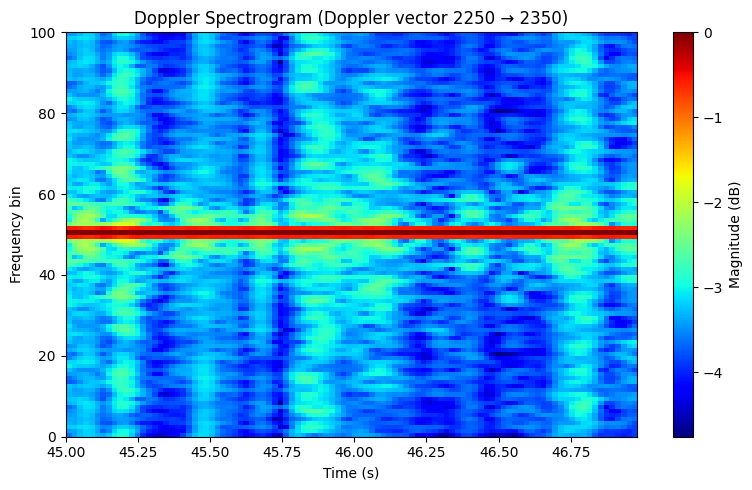

In [39]:
plot_doppler_spectrogram(47, csi_d_map, 100)